In [ ]:
import pandas as pd

df = pd.read_csv("/content/diabetes_binary_health_indicators_BRFSS2015 (1).csv")

In [ ]:
selected_features_final = [
    'GenHlth', 'HighBP', 'BMI', 'DiffWalk', 'HighChol',
    'Age', 'HeartDiseaseorAttack', 'PhysHlth', 'MentHlth', 'Income'
]

X = df[selected_features_final]
y = df["Diabetes_binary"]

Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
#SMOTE
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

In [ ]:
#Train XGBoost
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train_res, y_train_res)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)

**Evaluation**

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]


print("Accuracy:", accuracy_score(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_prob))
print(classification_report(y_test, y_pred))

Accuracy: 0.8614990025648332
AUC: 0.8185013121508607
              precision    recall  f1-score   support

         0.0       0.89      0.96      0.92     12107
         1.0       0.49      0.27      0.35      1929

    accuracy                           0.86     14036
   macro avg       0.69      0.61      0.64     14036
weighted avg       0.84      0.86      0.84     14036



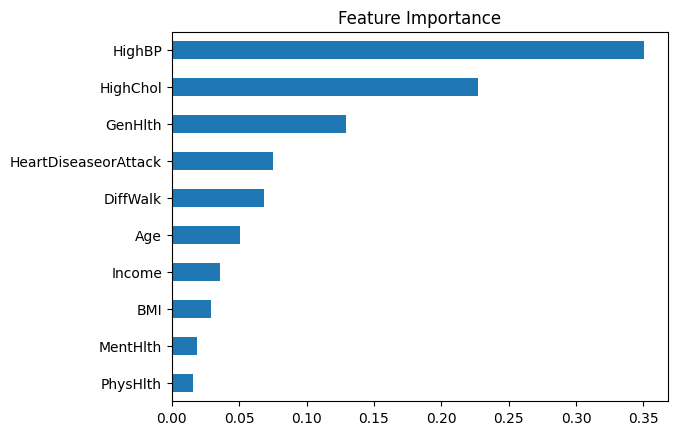

In [ ]:
#Feature Importance
import matplotlib.pyplot as plt
import pandas as pd

importance = model.feature_importances_

pd.Series(importance, index=selected_features_final)\
    .sort_values()\
    .plot(kind='barh')

plt.title("Feature Importance")
plt.show()

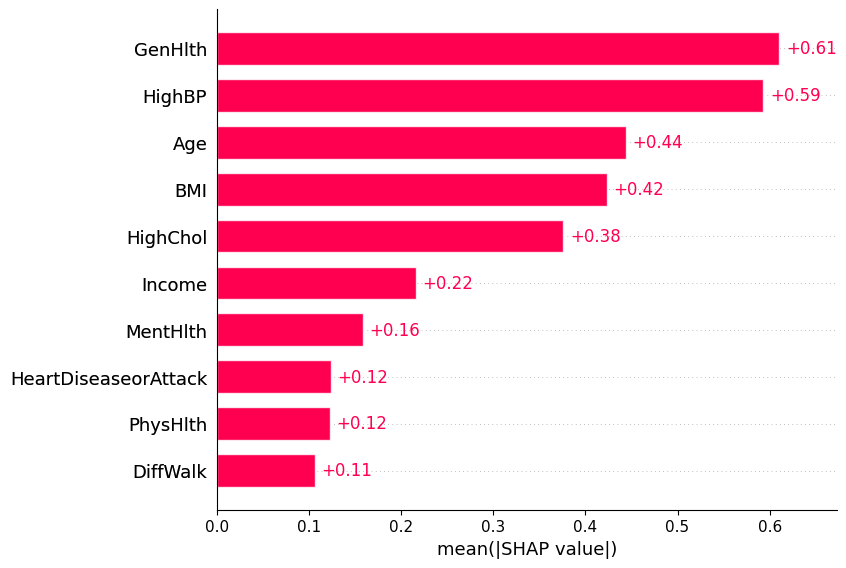

In [ ]:
import shap
#SHAP bar
explainer = shap.Explainer(model)
shap_values = explainer(X_test)

shap.plots.bar(shap_values)

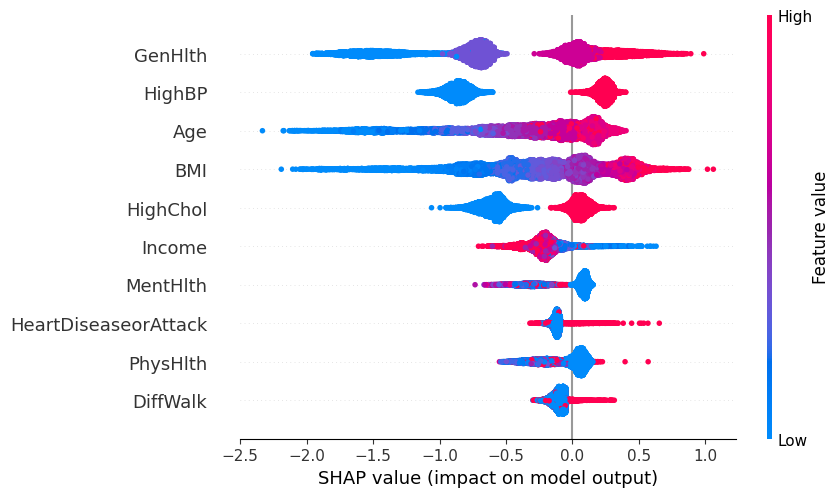

In [ ]:
#SHAP beeswarm
explainer = shap.Explainer(model)
shap_values = explainer(X_test)

shap.plots.beeswarm(shap_values)